# 📊 Analitik Harga Kartu Pokemon
Notebook ini digunakan untuk memuat dataset dan mencari korelasi fitur (Rarity, HP, Tahun) terhadap harga.

In [1]:
import pandas as pd
import os

# Memuat dataset
dataset_path = r'Data/backend/dataset/pokemon_cards_dataset_cleaned.csv'
df = pd.read_csv(dataset_path, low_memory=False)
print('Dataset dimuat dengan', df.shape[0], 'baris')

Dataset dimuat dengan 20617 baris


### 1. Data Cleaning & Feature Engineering
Ubah HP menjadi angka, dan buat Mapping untuk Rarity.

In [2]:
# 1. Bersihkan HP (ubah ke numerik)
df['hp'] = pd.to_numeric(df['hp'], errors='coerce')

# 2. Mapping Rarity ke Skor Angka
rarity_mapping = {
    'Common': 1, 'Uncommon': 2, 'Rare': 3, 'Rare Holo': 4, 'Promo': 4,
    'Rare Ultra': 5, 'Ultra Rare': 5, 'Double Rare': 5,
    'Rare Holo EX': 6, 'Rare Holo V': 6, 'Rare Holo GX': 6,
    'Rare Secret': 7, 'Rare Rainbow': 7, 'Illustration Rare': 7,
    'Special Illustration Rare': 8, 'Hyper Rare': 9
}
# Buat kolom baru 'rarity_score'
df['rarity_score'] = df['rarity'].map(rarity_mapping).fillna(3)

print('Data HP dan Rarity berhasil diproses!')

Data HP dan Rarity berhasil diproses!


### 2. Uji Korelasi
Melihat faktor apa yang paling mendikte harga

Nilai Korelasi Terhadap Harga:
effective_market_price    1.000000
rarity_score              0.195164
hp                        0.070577
release_year             -0.140107
Name: effective_market_price, dtype: float64


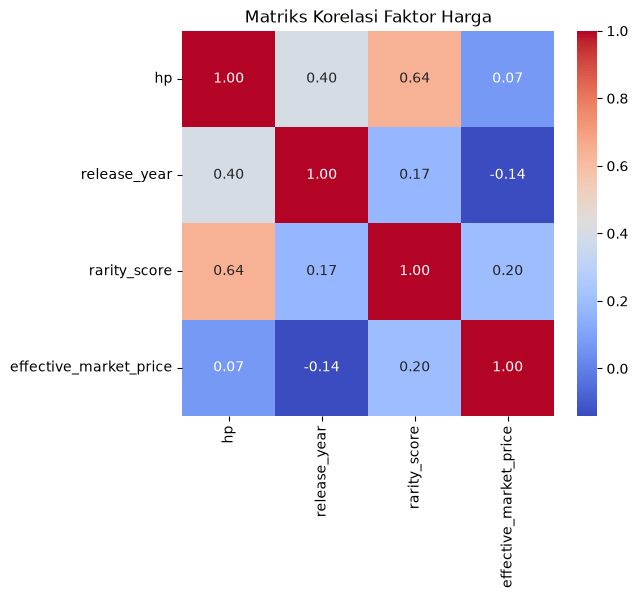

In [3]:
# Pastikan matplotlib & seaborn terinstall: !pip install matplotlib seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Pilih hanya kolom angka
kolom_analisis = ['hp', 'release_year', 'rarity_score', 'effective_market_price']
df_korelasi = df[kolom_analisis].dropna()

# Hitung matriks korelasi
corr_matrix = df_korelasi.corr()
print('Nilai Korelasi Terhadap Harga:')
print(corr_matrix['effective_market_price'].sort_values(ascending=False))

# Visualisasi Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Faktor Harga')
plt.show()

### 3. Visualisasi Heatmap Korelasi
Menampilkan matriks korelasi antar variabel angka dalam bentuk peta warna (Heatmap).

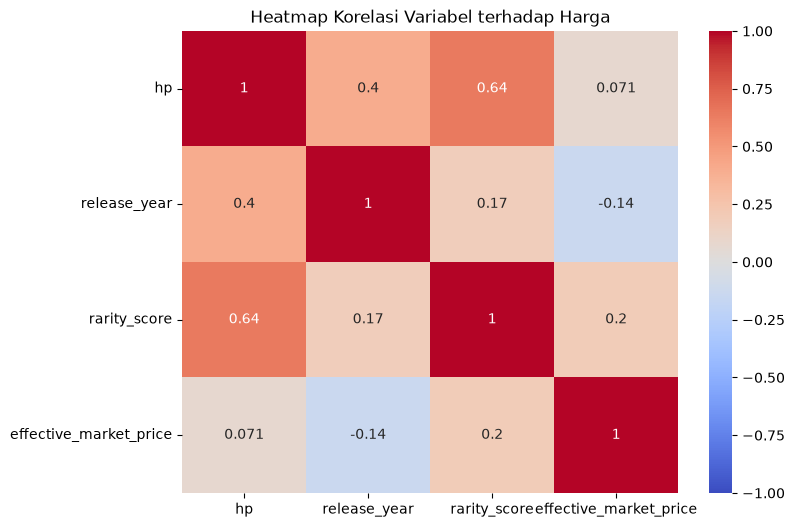

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Variabel terhadap Harga')
plt.show()

### 4. Pendalaman: Rata-rata Harga Berdasarkan Jenis Rarity
Melihat secara spesifik jenis 'Rarity' apa yang paling berdampak pada harga.

C:\Users\udiad\AppData\Local\Temp\ipykernel_6576\161290209.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rarity_price, x='rarity', y='effective_market_price', palette='viridis')


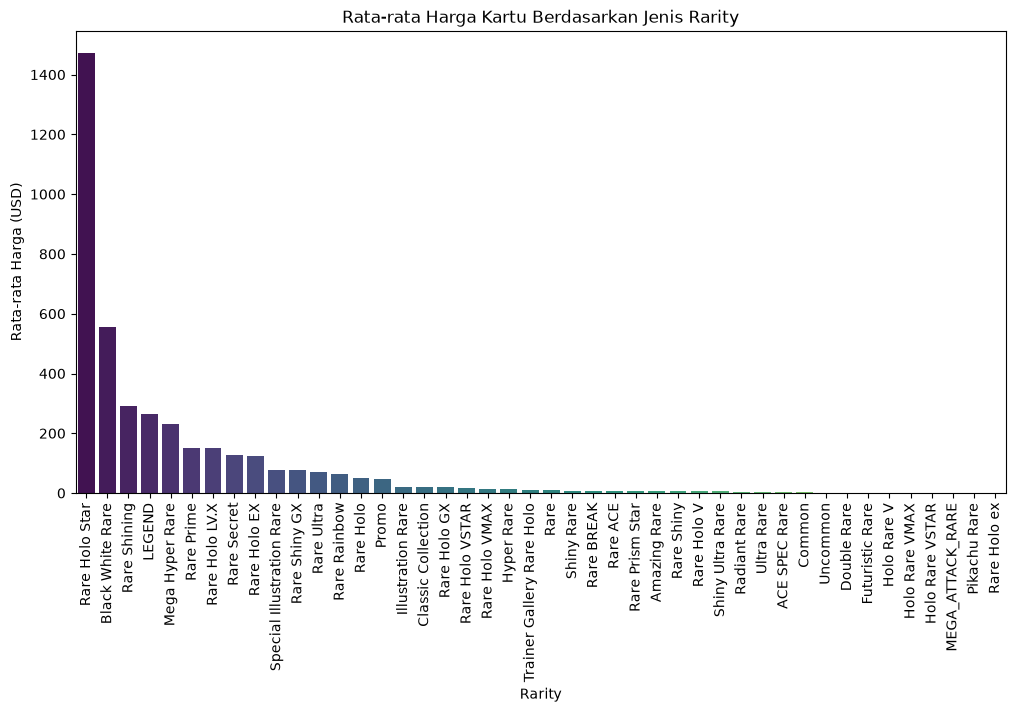

,rarity,effective_market_price
0,Rare Holo Star,1472.113600
1,Black White Rare,554.760000
2,Rare Shining,291.164375
3,LEGEND,263.654444
4,Mega Hyper Rare,231.660000
5,Rare Prime,152.157308
6,Rare Holo LV.X,151.653750
7,Rare Secret,127.396800
8,Rare Holo EX,124.380881
9,Special Illustration Rare,78.317747


In [ ]:
# Kelompokkan berdasarkan rarity asli (bukan skor) dan hitung rata-rata harga
df_rarity_price = df.groupby('rarity')['effective_market_price'].mean().sort_values(ascending=False).reset_index()

# Visualisasi Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=df_rarity_price, x='rarity', y='effective_market_price', palette='viridis')
plt.xticks(rotation=90)
plt.title('Rata-rata Harga Kartu Berdasarkan Jenis Rarity')
plt.xlabel('Rarity')
plt.ylabel('Rata-rata Harga (USD)')
plt.show()

display(df_rarity_price.head(10))